# Step 0

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (11, 6)


df_raw= pd.read_csv("/Users/chris/Desktop/ChristianBDA2026/data/Symbol_Info_extended.csv")

print("Dataset shape:", df_raw.shape)
df_raw.head()

# My student ID = 2, so Canada
canada = df_raw[df_raw["country"] == 'Canada'].copy()

canada["market_cap_b"] = canada["market_cap"] / 1e9

# We want to visualized the largest Canadian company

print("Largest Canadian companies — selection metrics:")
print(

    canada.sort_values("market_cap_b", ascending= False)
    .head(10)[["symbol", "company_name", "sector", "industry", "market_cap_b", "profit_margins", "revenue_growth", "return_on_equity"]]
    .to_string(index = False)
)


# CHOICE: Shopify (SHOP)

# From the table above, SHOP is the only Technology company among banks and energy
# 3rd-largest Canadian company by market cap (134B)
# It has the highest growth (revenue_growth +34%) but the lowest margins (11%)
# This tension (expensive & growing vs modest margins, solid balance sheet) makes
# the four business questions richer to analyse than an "all-good" name like AEM
SELECTED_SYMBOL = "SHOP"

# Isolate the selected company's row to confirm the choice.
selected = canada[canada["symbol"] == SELECTED_SYMBOL]
print("\nSelected company:")
print(selected[["symbol", "company_name", "sector", "industry", "market_cap_b"]].to_string(index=False))

Dataset shape: (3070, 21)
Largest Canadian companies — selection metrics:
symbol                       company_name             sector               industry  market_cap_b  profit_margins  revenue_growth  return_on_equity
    RY               Royal Bank of Canada Financial Services    Banks - Diversified    263.794885         0.33137           0.075           0.15395
    TD          The Toronto-Dominion Bank Financial Services    Banks - Diversified    187.573633         0.33022           0.211           0.17815
  SHOP                       Shopify Inc.         Technology Software - Application    133.658427         0.10771           0.343           0.11311
   ENB                      Enbridge Inc.             Energy    Oil & Gas Midstream    126.741742         0.10000           0.208           0.10127
   BMO                   Bank of Montreal Financial Services    Banks - Diversified    113.442759         0.27076           0.100           0.10471
    CM Canadian Imperial Bank of Comme

# Step 1


In [2]:
# Start from the raw dataset
df = df_raw.copy()

# Keep only the variables required by this homework:
# identification & peer-selection variables + the financial variables
cols_needed = [
    "symbol", "company_name", "sector", "industry", "country", "market_cap",
    "return_on_assets", "return_on_equity", "profit_margins",
    "pe_trailing", "price_to_book", "revenue_growth",
    "debt_to_equity", "free_cashflow",
]
df = df[cols_needed].copy()


df = df.replace([np.inf, -np.inf], np.nan)

# Readable columns: billions and percentages
df["market_cap_b"]        = df["market_cap"]       / 1e9
df["free_cashflow_b"]     = df["free_cashflow"]    / 1e9
df["profit_margin_pct"]   = df["profit_margins"]   * 100
df["return_on_assets_pct"]= df["return_on_assets"] * 100
df["return_on_equity_pct"]= df["return_on_equity"] * 100
df["revenue_growth_pct"]  = df["revenue_growth"]   * 100

# Label column, fall back to symbol when company_name is missing
df["label"] = df["company_name"].fillna(df["symbol"])

print("Working dataset shape:", df.shape)
df.head()


Working dataset shape: (3070, 21)


,symbol,company_name,sector,industry,country,market_cap,return_on_assets,return_on_equity,profit_margins,pe_trailing,price_to_book,revenue_growth,debt_to_equity,free_cashflow,market_cap_b,free_cashflow_b,profit_margin_pct,return_on_assets_pct,return_on_equity_pct,revenue_growth_pct,label
0,A,"Agilent Technologies, Inc.",Healthcare,Diagnostics & Research,United States,3.248796e+10,0.08533,0.19946,0.18259,25.377481,4.704534,0.070,51.390,8.558750e+08,32.487961,0.855875,18.259001,8.533000,19.945998,7.0,"Agilent Technologies, Inc."
1,AA,Alcoa Corporation,Basic Materials,Aluminum,United States,1.883646e+10,0.04241,0.15427,0.08171,18.302563,2.759500,-0.052,37.019,1.087375e+09,18.836457,1.087375,8.171000,4.241000,15.427000,-5.2,Alcoa Corporation
2,AAL,American Airlines Group Inc.,Industrials,Airlines,United States,9.160185e+09,0.01846,NaN,0.00361,44.677420,-2.246918,0.108,NaN,8.611250e+08,9.160185,0.861125,0.361000,1.846000,NaN,10.8,American Airlines Group Inc.
3,AAMI,Acadian Asset Management Inc.,Financial Services,Asset Management,United States,2.550323e+09,0.12664,1.11725,0.13785,30.459576,32.910347,0.393,346.579,1.208000e+08,2.550323,0.120800,13.785000,12.663999,111.725000,39.3,Acadian Asset Management Inc.
4,AAOI,"Applied Optoelectronics, Inc.",Technology,Communication Equipment,United States,1.456326e+10,-0.03317,-0.06126,-0.08548,NaN,12.958943,0.514,25.356,-4.455833e+08,14.563260,-0.445583,-8.548001,-3.317000,-6.126000,51.4,"Applied Optoelectronics, Inc."


In [3]:
# excluding companies with market_cap <= 0
# A non-positive market cap is a data-quality issue, not a tiny company


df_peers = df[df["market_cap"] > 0].copy()

# set non-positive pe_trailing and price_to_book to nan

for frame in (df, df_peers):
    frame.loc[frame["pe_trailing"]   <= 0, "pe_trailing"]   = np.nan
    frame.loc[frame["price_to_book"] <= 0, "price_to_book"] = np.nan

print("Peer universe (market_cap > 0):", df_peers.shape)
print("Valid pe_trailing values:", df_peers["pe_trailing"].notna().sum())
print("Valid price_to_book values:", df_peers["price_to_book"].notna().sum())

Peer universe (market_cap > 0): (2970, 21)
Valid pe_trailing values: 2088
Valid price_to_book values: 2798


# Step 2

In [4]:
# All three groups share the same rule: take the top 10 by market cap, and if the
# selected company is not already inside, add it

def ensure_selected(group_df, universe_df, symbol):
    if symbol in group_df["symbol"].values:
        return group_df
    selected_row = universe_df[universe_df["symbol"] == symbol]
    return pd.concat([group_df, selected_row], ignore_index=False)

In [5]:
# Group A — Same industry.


selected_industry = df_peers.loc[df_peers["symbol"] == SELECTED_SYMBOL, "industry"].iloc[0]

group_a = df_peers[df_peers["industry"] == selected_industry].copy()
group_a = group_a.sort_values("market_cap_b", ascending=False).head(10)
group_a = ensure_selected(group_a, df_peers, SELECTED_SYMBOL)

print(f"Group A — industry '{selected_industry}': {len(group_a)} companies")
print(group_a[["symbol", "label", "country", "market_cap_b"]].to_string(index=False))

Group A — industry 'Software - Application': 10 companies
symbol                           label       country  market_cap_b
   CRM                Salesforce, Inc. United States    147.306938
  UBER         Uber Technologies, Inc. United States    146.196726
  SHOP                    Shopify Inc.        Canada    133.658427
   NOW                ServiceNow, Inc. United States    105.327485
  CDNS    Cadence Design Systems, Inc. United States    103.042097
  ADBE                      Adobe Inc. United States     98.931991
   ADP Automatic Data Processing, Inc. United States     90.064126
  INTU                     Intuit Inc. United States     87.515423
  DDOG                   Datadog, Inc. United States     79.137071
  SNOW                  Snowflake Inc. United States     59.685020


In [6]:
# Group B — Same geographic group.

group_b = df_peers[df_peers["country"] == "Canada"].copy()
group_b = group_b.sort_values("market_cap_b", ascending=False).head(10)
group_b = ensure_selected(group_b, df_peers, SELECTED_SYMBOL)

print(f"Group B — Canada: {len(group_b)} companies")
print(group_b[["symbol", "label", "sector", "market_cap_b"]].to_string(index=False))

Group B — Canada: 10 companies
symbol                              label             sector  market_cap_b
    RY               Royal Bank of Canada Financial Services    263.794885
    TD          The Toronto-Dominion Bank Financial Services    187.573633
  SHOP                       Shopify Inc.         Technology    133.658427
   ENB                      Enbridge Inc.             Energy    126.741742
   BMO                   Bank of Montreal Financial Services    113.442759
    CM Canadian Imperial Bank of Commerce Financial Services    106.291225
   CNQ Canadian Natural Resources Limited             Energy    101.386363
    BN             Brookfield Corporation Financial Services    101.338235
   BNS            The Bank of Nova Scotia Financial Services     98.243772
   AEM         Agnico Eagle Mines Limited    Basic Materials     87.961371


In [7]:
# Group C — Closest market capitalization.


selected_mcap = df_peers.loc[df_peers["symbol"] == SELECTED_SYMBOL, "market_cap"].iloc[0]

df_others = df_peers[df_peers["symbol"] != SELECTED_SYMBOL].copy()
df_others["mcap_distance"] = (df_others["market_cap"] - selected_mcap).abs()

group_c = df_others.sort_values("mcap_distance").head(10).drop(columns="mcap_distance")
group_c = ensure_selected(group_c, df_peers, SELECTED_SYMBOL)

print(f"Group C — closest market cap: {len(group_c)} companies")
print(group_c[["symbol", "label", "sector", "country", "market_cap_b"]].to_string(index=False))

Group C — closest market cap: 11 companies
symbol                           label             sector       country  market_cap_b
   PDD               PDD Holdings Inc.  Consumer Cyclical       Ireland    134.539428
   PLD                  Prologis, Inc.        Real Estate United States    136.028103
  IBKR Interactive Brokers Group, Inc. Financial Services United States    138.299736
    CB                   Chubb Limited Financial Services   Switzerland    127.175451
   ENB                   Enbridge Inc.             Energy        Canada    126.741742
   VRT              Vertiv Holdings Co        Industrials United States    125.780263
  BKNG           Booking Holdings Inc.  Consumer Cyclical United States    124.801925
    DE                 Deere & Company        Industrials United States    142.927282
  SPGI                 S&P Global Inc. Financial Services United States    123.609604
    MO              Altria Group, Inc. Consumer Defensive United States    123.404960
  SHOP     

# Step 3

## Business Question 1: Is the Company Profitable?

We evaluate profitability with two metrics: **profit_margins** and **return_on_equity**
For each metric we compare SHOP against the three peer groups (A = industry, B = Canada,
C = similar market cap), one chart per group. 
SHOP is highlighted in red and the peer median is marked. ROE can be negative (losses or negative book equity), so the zero line is annotated.

In [8]:


#horizontal bar chart of one metric for one peer group


# We define one function and reuse it for all 6 charts,

def plot_metric_vs_peers(group_df, metric_col, group_name, metric_label,
                         selected_symbol=SELECTED_SYMBOL, pct=True):
    # Clean missing values for this metric only
    data = group_df.dropna(subset=[metric_col]).copy()


    selected_has_value = selected_symbol in data["symbol"].values

    # Sort ascending so the largest bar sits at the top of the horizontal chart
    data = data.sort_values(metric_col, ascending=True)

    # Highlight the selected company in red, peers in blue
    colors = ["#E45756" if s == selected_symbol else "#4C78A8" for s in data["symbol"]]

    fig, ax = plt.subplots(figsize=(11, 6))
    ax.barh(data["symbol"], data[metric_col], color=colors)


    median_val = data[metric_col].median()
    ax.axvline(median_val, color="#F58518", linestyle="--", linewidth=2,
               label=f"Peer median: {median_val:.1f}{'%' if pct else ''}")

    # Zero line, important because ROE can be negative
    ax.axvline(0, color="black", linewidth=0.8)

    ax.set_title(f"{metric_label} — {group_name}")
    ax.set_xlabel(metric_label)
    ax.set_ylabel("Ticker")
    if pct:
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x:.0f}%"))
    ax.grid(axis="x", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend()


    for y, (val, sym) in enumerate(zip(data[metric_col], data["symbol"])):
        offset = (data[metric_col].max() - data[metric_col].min()) * 0.01
        ax.text(val + (offset if val >= 0 else -offset), y,
                f"{val:.1f}{'%' if pct else ''}",
                va="center", ha="left" if val >= 0 else "right", fontsize=8)


    if not selected_has_value:
        ax.text(0.5, 0.95, f"{selected_symbol}: no valid value for this metric",
                transform=ax.transAxes, ha="center", color="#E45756")

    plt.tight_layout()
    plt.show()

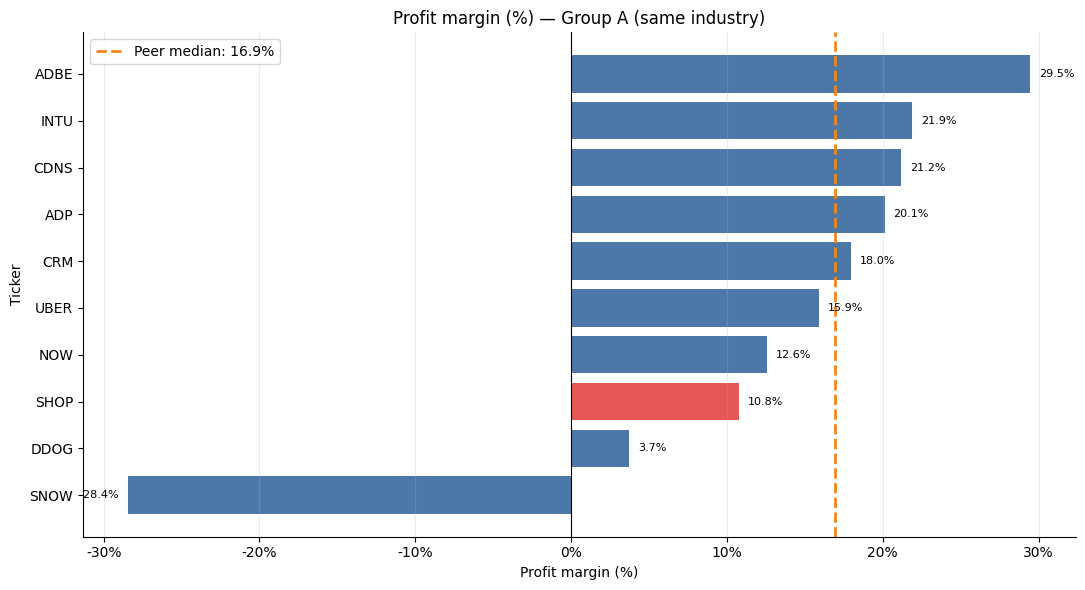

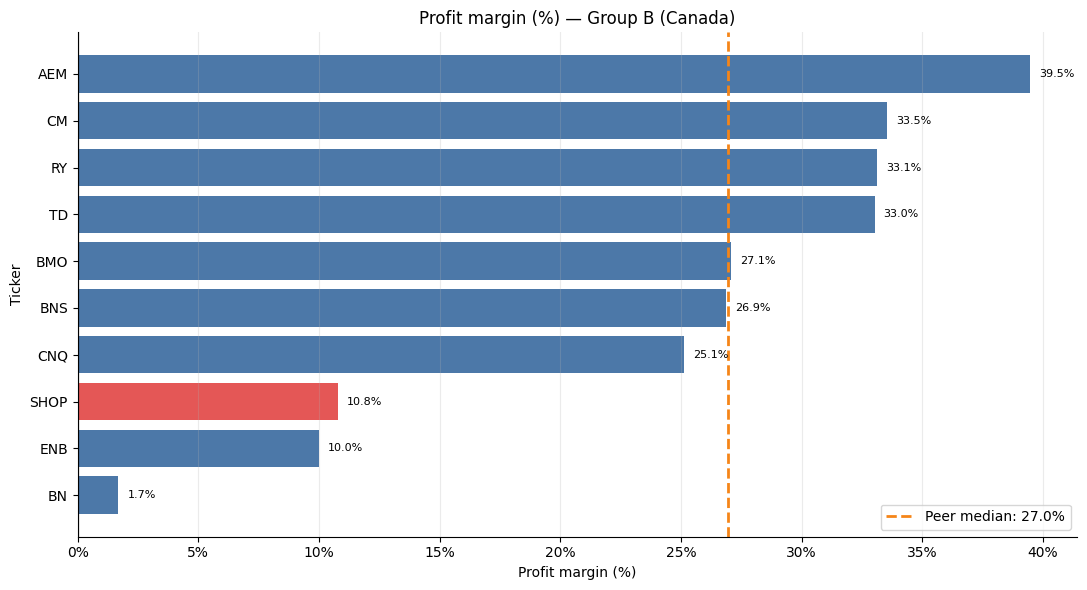

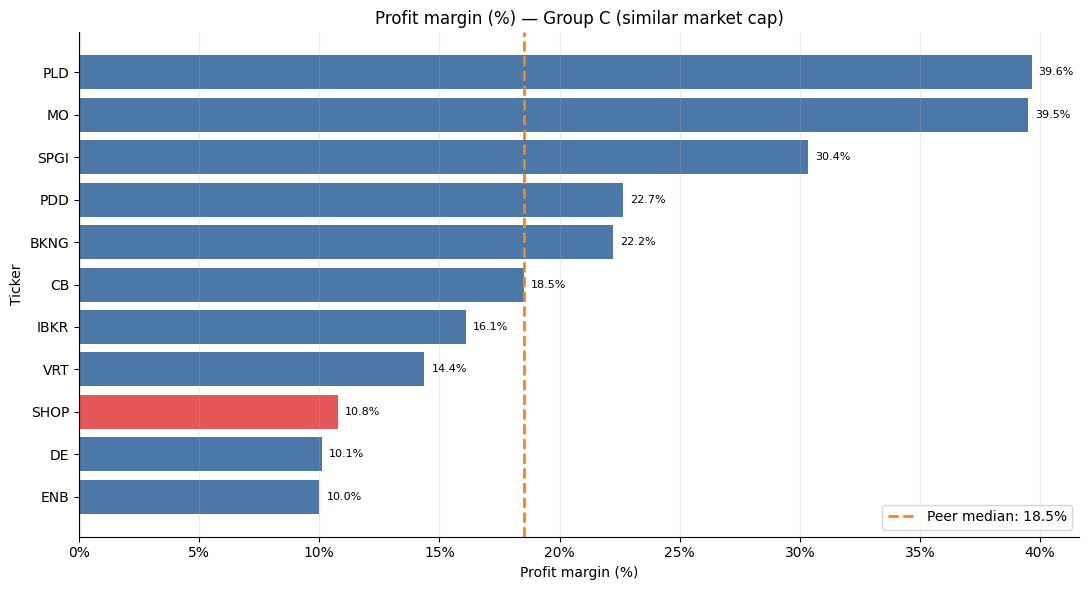

In [9]:
# Metric 1: profit_margins, one chart per peer group
plot_metric_vs_peers(group_a, "profit_margin_pct", "Group A (same industry)", "Profit margin (%)")
plot_metric_vs_peers(group_b, "profit_margin_pct", "Group B (Canada)",        "Profit margin (%)")
plot_metric_vs_peers(group_c, "profit_margin_pct", "Group C (similar market cap)", "Profit margin (%)")

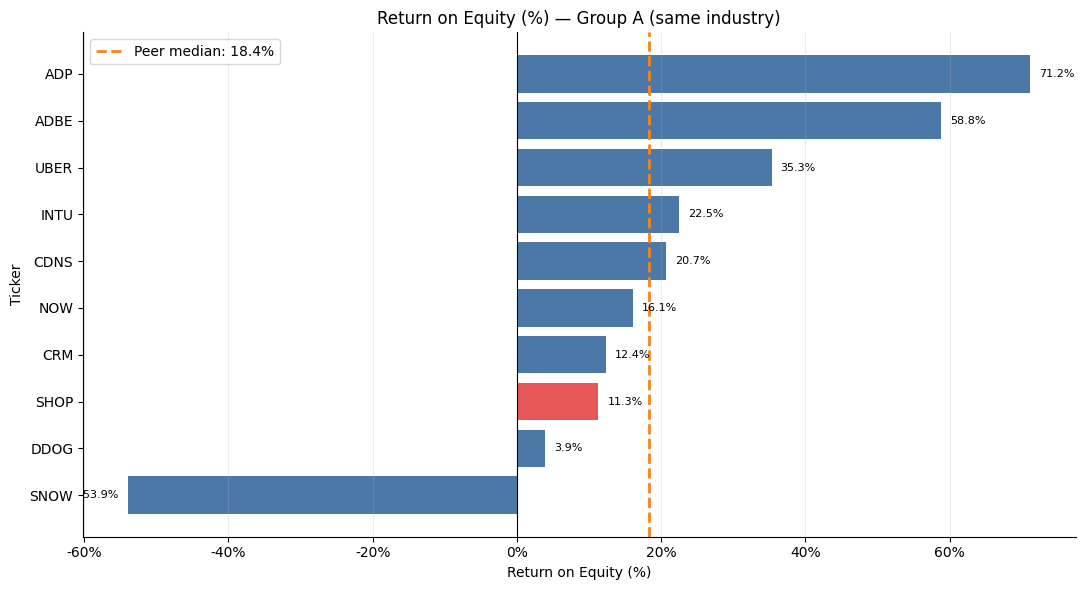

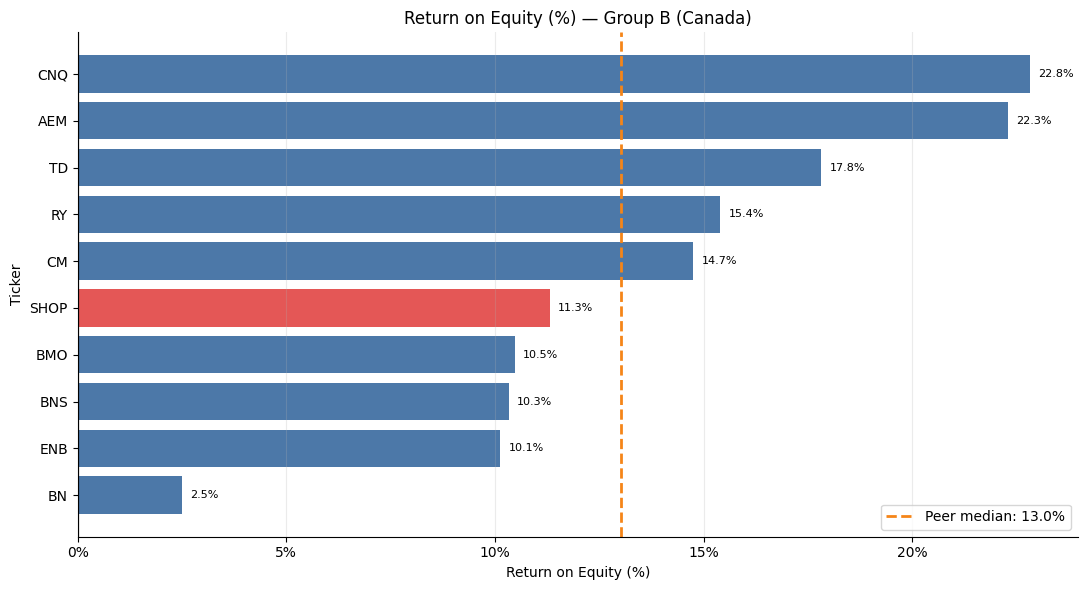

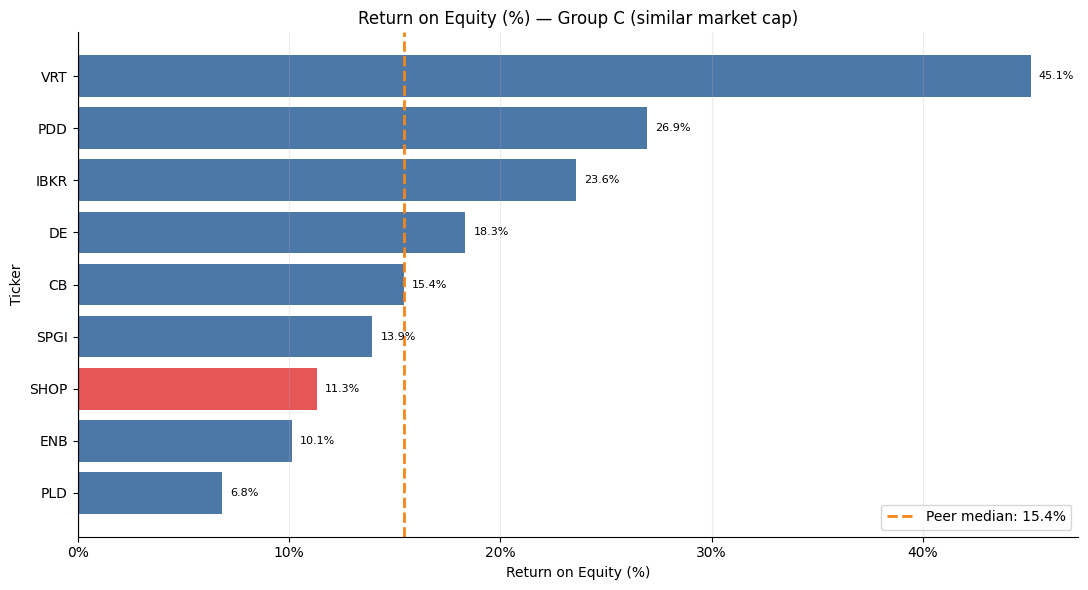

In [10]:
# Metric 2: return_on_equity, one chart per peer group
# ROE can be negative, so the zero line annotated in the helper matters here
plot_metric_vs_peers(group_a, "return_on_equity_pct", "Group A (same industry)", "Return on Equity (%)")
plot_metric_vs_peers(group_b, "return_on_equity_pct", "Group B (Canada)", "Return on Equity (%)")
plot_metric_vs_peers(group_c, "return_on_equity_pct", "Group C (similar market cap)", "Return on Equity (%)")

### Interpretation — Profitability

Right now, **SHOP** is running a profit margin of about 11% and pulling in a matching ROE of 11%. But how do these numbers actually stack up when we look at the bigger picture?
The Peer Group Showdown

- **Vs. Software Peers (Group A)**: When put next to other tech players, Shopify lands below the median for both metrics (where margins usually hover around 17% and ROE sits near 18%). Compared to mature software firms that are actively milking their bottom line, Shopify looks only modestly profitable. This is typical for a company that’s still aggressively reinvesting its cash into growth rather than trying to maximize short term margins.
  
- **Vs. the Canadian Market (Group B)**: At first glance, SHOP’s 11% margin looks weak against the Canadian median of 27%. However, that group is heavily weighted toward major banks with structurally massive margins, so that gap is completely normal. If you switch the focus to ROE, the story is much tighter: SHOP (11%) is just quite behind the Canadian median (13%).
  
- **Vs. Similarly Sized Companies (Group C)**: below the median on both metrics (margin 18%, ROE 15%).

Shopify is genuinely profitable (no red ink here), but its profitability is modest and generally tracks below peer medians. Shopify looks a bit sluggish when compared to top tier software giants, but it holds its own against Canadian large caps on an ROE basis.


# Step 4

## Step 4 — Business Question 2: Is the Company Expensive or Cheap?

We evaluate valuation with **pe_trailing** and **price_to_book**, using **only Group A**
(same industry). As we know, valuation multiples are tightly linked to the
sector, so comparing them against banks or unrelated industries (Groups B and C) would
not be meaningful. Values ≤ 0 were already set to NaN in Step 1. Charts are sorted ascending
and SHOP is highlighted.

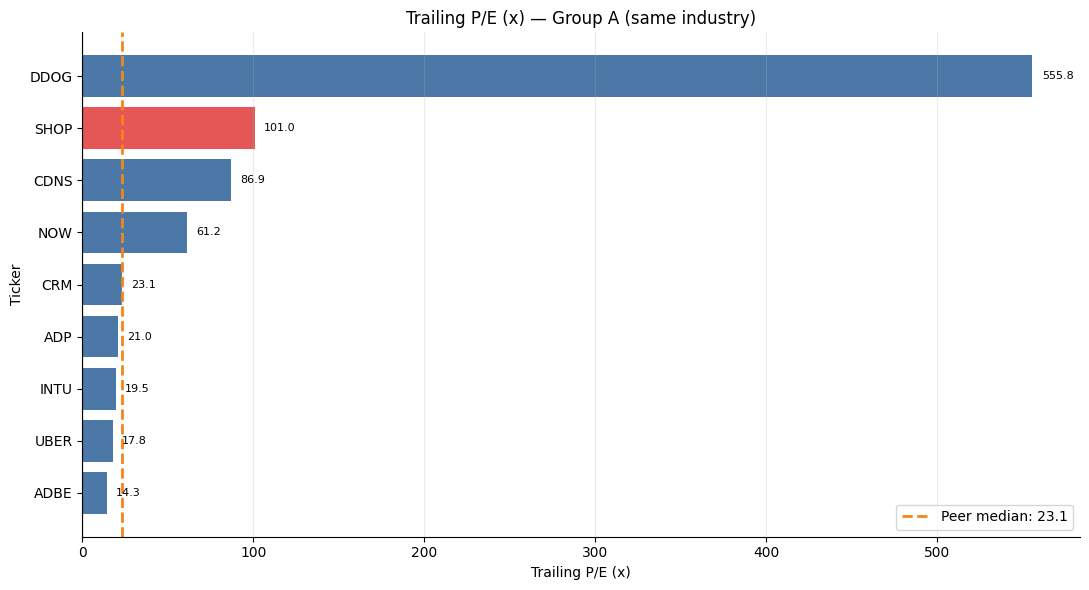

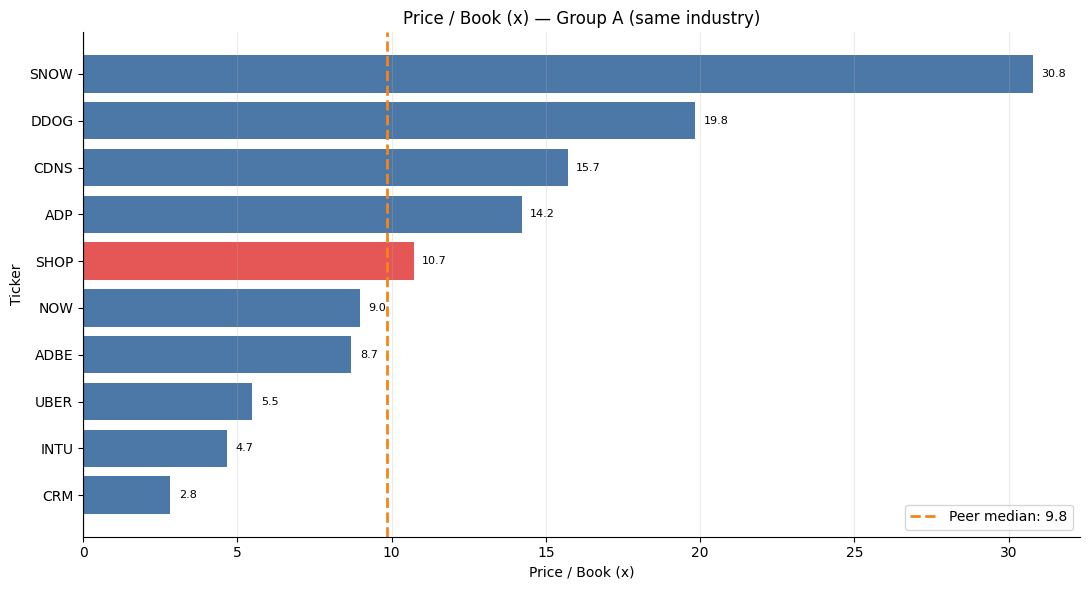

In [11]:
# --- Valuation: pe_trailing and price_to_book, GROUP A ONLY ---
# Multiples are sector-specific, so we only compare within the same industry (Group A)
# pct=False because these are multiples (x), not percentages
plot_metric_vs_peers(group_a, "pe_trailing",   "Group A (same industry)", "Trailing P/E (x)",   pct=False)
plot_metric_vs_peers(group_a, "price_to_book", "Group A (same industry)", "Price / Book (x)",   pct=False)

### Interpretation — Valuation

**Trailing P/E (Price-to-Earnings)**
Shopify is currently trading at a staggering 101x, which is way above the Group A median of about 23x. In this space, only names like DDOG (556x) and CDNS (87x) command a higher premium. Meanwhile, established giants like ADBE, INTU, CRM, and UBER are sitting comfortably in the 14x to 23x range. If we judge it strictly by its current earnings, SHOP is undeniably expensive.

**Price / Book (P/B Ratio)**
However, look at the book value and the picture changes. SHOP trades at roughly 10.7x, which is pretty much in line with the software peer median of 9.8x. On a book-value basis, its pricing looks completely reasonable—and sits well below high-flyers like SNOW (31x) and DDOG (20x).

**Expensive, Cheap, or Fairly Valued?**
We are looking at a classic split story: on earnings, SHOP looks pricey; on book value, it looks perfectly average for the software industry. Why the disagreement?
It all comes down to timing. The P/E ratio reflects current earnings. Right now, Shopify’s profits are still relatively small compared to its stock price for one specific reason: the company is aggressively reinvesting for growth rather than trying to maximize immediate profits. This ties back perfectly to the modest margins we ran into during Step 3.
**Does the High Valuation Hide Weak Fundamentals?**
This isn’t a case of a "cheap" stock trying to mask underlying problems—it’s actually the exact opposite. That massive P/E ratio is a growth premium. Essentially, the market is happily paying a premium today because it anticipates massive earnings tomorrow.
Whether that premium is truly justified depends entirely on one thing: is Shopify's growth actually strong enough to back it up? That is exactly what we will unpack in Step 5.

# Step 5

### Step 5 - Business Question 3: Is Shopify growing?

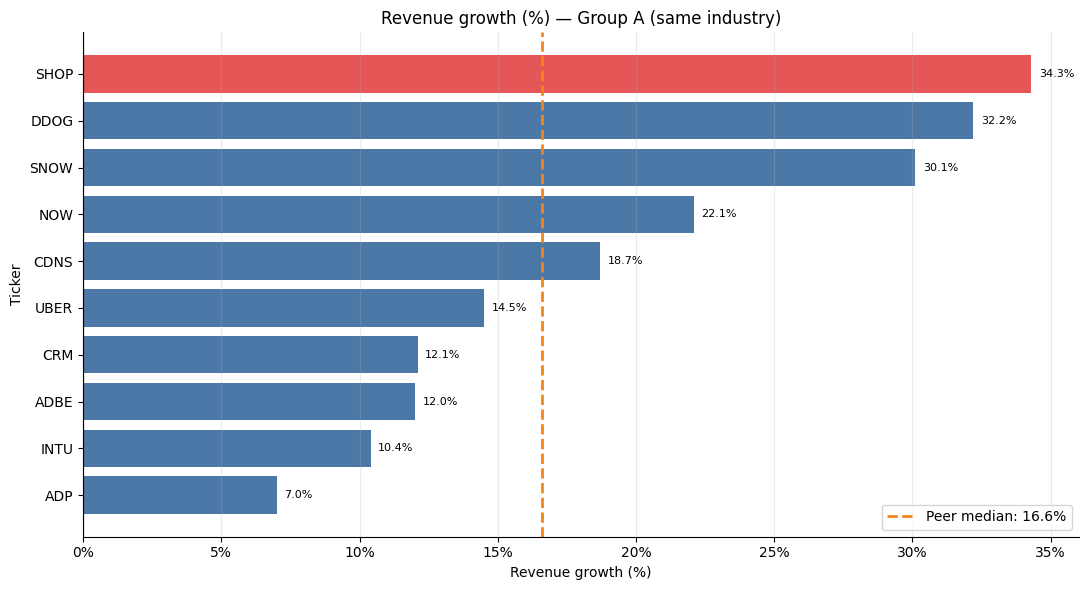

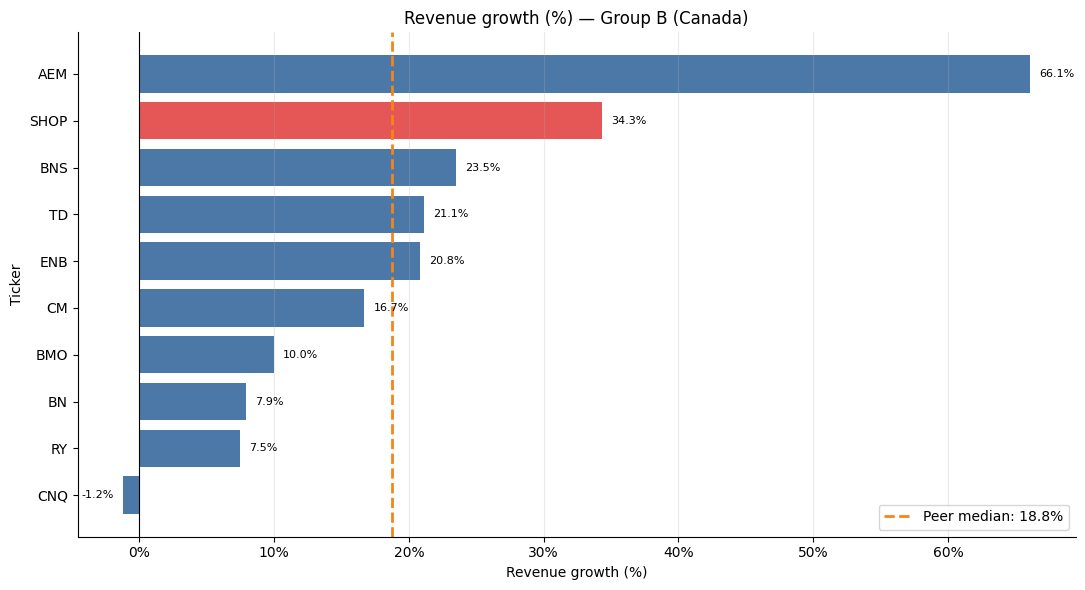

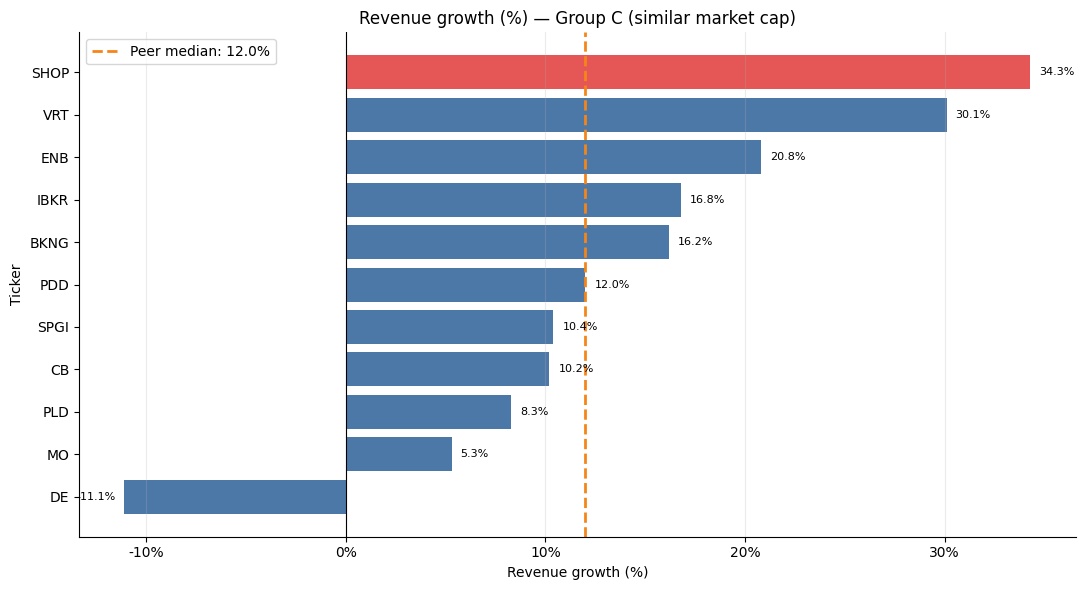

In [12]:

# Metric — Revenue Growth (one chart per peer group)


# revenue_growth is in decimal, We create a percentage column

# peer groups
for g in (group_a, group_b, group_c):
    g["revenue_growth_pct"] = g["revenue_growth"] * 100

# Reuse the same helper as Steps 3-4, one chart per peer group.
plot_metric_vs_peers(group_a, "revenue_growth_pct", "Group A (same industry)",     "Revenue growth (%)")
plot_metric_vs_peers(group_b, "revenue_growth_pct", "Group B (Canada)",            "Revenue growth (%)")
plot_metric_vs_peers(group_c, "revenue_growth_pct", "Group C (similar market cap)", "Revenue growth (%)")

Shopify's revenue growth is clocking in at an impressive **+34.3%**, a remarkably strong performance that stands out across all three peer groups:

- **Vs. Software Peers (Group A)**: This is the highest growth rate in the entire group, landing way above the peer median (17%). It even edges out other fast-growers like DDOG (+32%) and SNOW (+30%). Meanwhile, mature tech giants like ADP, INTU, and ADBE are moving at a much slower pace, hovering between 7% and 12%.
  
- **Vs. the Canadian Market (Group B)**: Shopify is second only to AEM (+66%) and sits comfortably above the national median (19%). Since the other massive Canadian players are mostly banks and energy companies growing at a modest 7% to 23%, SHOP clearly stands out as the high-growth outlier in its home country.

- **Vs. Similarly Sized Companies (Group C)**: Even among businesses of its own scale, Shopify takes the top spot, leaving the group median (12%) in the dust. The only peer of similar size that comes close is VRT (+30%), while DE is actually seeing a decline (11%).

The Big Picture: Is the Growth Real and Beating the Competition?
Without a doubt. Growth is strongly positive and outpaces competitors no matter how you slice the data. In the software industry, anything north of 20% is considered a stellar year; hitting +34% is definitive proof that Shopify is still firmly in its prime expansion phase.

Does This Justify the High Valuation? (Step 4)
Yes, this is the missing piece of the puzzle. That massive 101x P/E ratio we looked at earlier isn't a fluke it’s a growth premium. Investors are happily paying up today because they are banking on huge future earnings, and this +34.3% growth rate is the hard evidence backing up that bet. Ultimately, the premium valuation and the aggressive growth are just two sides of the same coin.

# Step 6

## Step 6 — Business Question 4: Is the Company Financially Solid?

We evaluate financial strength with **debt_to_equity** and **free_cashflow**, using **only
Group A** (same industry). debt_to_equity is a percentage (lower is better); free_cashflow
is in absolute terms and can be negative (negative FCF is not automatically bad, it can
reflect heavy investment in a growth phase). No D/E outlier above 1000% appears in Group A,
so no axis cap is needed.

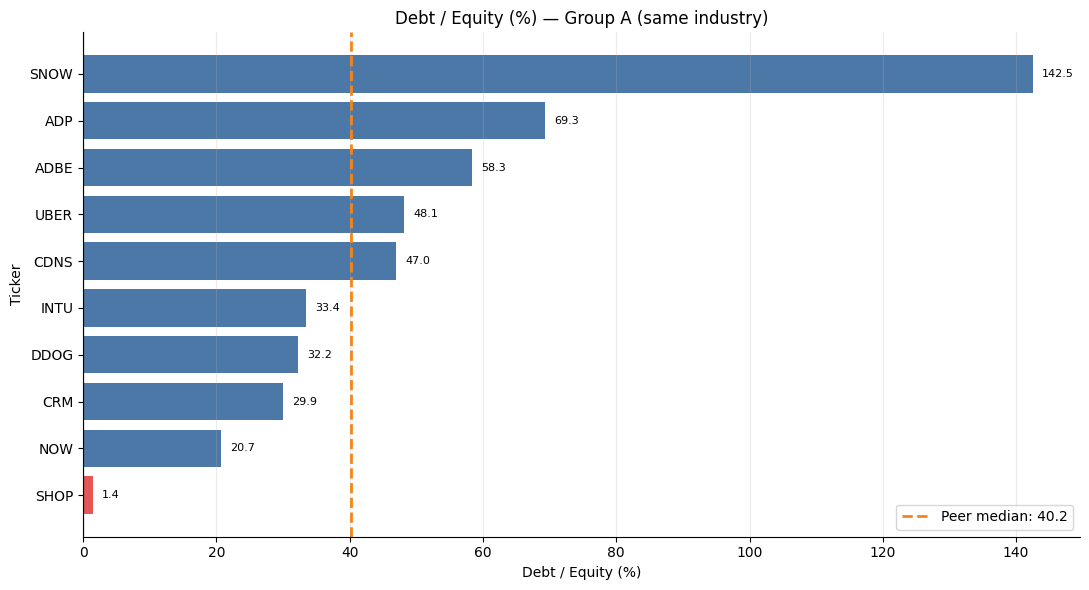

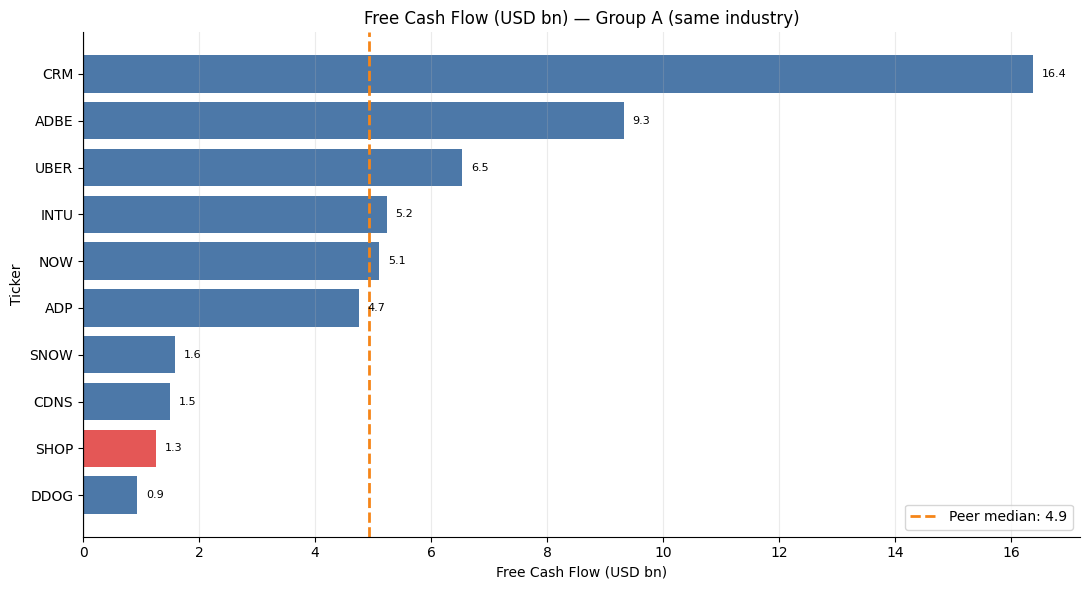

In [13]:


# debt_to_equity & free_cashflow (GROUP A ONLY)


# debt_to_equity is already a percentage 
# Group A, so no cap is needed, free_cashflow we express in billions for readability
group_a["free_cashflow_b"] = group_a["free_cashflow"] / 1e9

plot_metric_vs_peers(group_a, "debt_to_equity",  "Group A (same industry)", "Debt / Equity (%)", pct=False)
plot_metric_vs_peers(group_a, "free_cashflow_b", "Group A (same industry)", "Free Cash Flow (USD bn)", pct=False)

- **Debt-to-Equity (D/E Ratio)**: Shopify’s D/E sits at a tiny 1.4%, making it by far the lowest in Group A (where the median is around 40%). The company is running almost entirely on equity. This is a highly conservative balance sheet, leaving Shopify with plenty of room to take on debt for major acquisitions or expansions down the road if they want to.
- **Free Cash Flow (FCF)**: Shopify is pulling in a healthy +$1.26B in free cash flow. While that's smaller in absolute terms than cash juggernauts like CRM ($16B) or ADBE ($9B)—which makes sense given Shopify's smaller revenue footprint—it is firmly positive. Crucially, no one in Group A is burning cash, and SHOP sits comfortably among the cash-generating winners.

**Strong, Weak, or Mixed?**
Clearly strong, combining near-zero debt with positive free cash flow gives Shopify one of the safest, most bulletproof financial profiles a growth company can have. There are zero red flags on this balance sheet.
When you pair this financial stability with the explosive growth we saw in Step 5, it’s easy to see why the market is willing to pay such a steep price for the stock (Step 4): investors are paying a premium for growth, but the downside is heavily cushioned by a rock-solid, low-risk financial foundation.

# Final Summary
## Selected Company: Shopify Inc. (SHOP) — Canada, Software - Application

--**Why Shopify Was Chosen (and how it ties back to Homework 1)**--
The geographic focus for this assignment is Canada. If you look at the largest Canadian companies, the list is heavily dominated by diversified banks and energy producers. Shopify stands out as the only large cap Technology name in the mix, and it’s the third-largest Canadian company overall ($134B market cap).
I chose Shopify because it perfectly fits the exact same framework I used to analyze companies in Homework 1. Back then, when looking at the Consumer Cyclical sector, I built a "growth vs margin" quadrant map to target the high-growth quadrant (spotlighting fast moving names like ABNB, CMG, and YUM). Shopify brings that exact same flavor but to a completely different sector. It is the clearest "growth story" available in the Canadian group, but it comes with a fascinating twist: explosive growth paired with very modest current margins, this allowed me to take the Homework 1 playbook (growth, profitability, valuation, and risk) and test it on a totally different financial blueprint.

--**Profitability**--
Shopify is profitable, but nobody would call it high margin just yet. Its profit margin and ROE both hover right around 11%, landing below the median for its software peers in Group A (where margins average 17% and ROE hits 18%). Compared to its Canadian peers in Group B, Shopify’s profit margin looks quite low mainly because Canadian banks run on structurally massive 27% margins. However, look at ROE, and Shopify (11%) is nearly neck and neck with the Canadian median (13%). Both metrics point to the same reality: its profitability is real but modest, which is exactly what you expect from a company that prefers to reinvest for future growth rather than optimize today's bottom line.

--**Valuation: Does the Growth Back It Up?**--
Depending on how you look at it, Shopify is either incredibly expensive or completely average. On an earnings basis, it’s pricey, trading at a trailing P/E of 101x compared to the Group A median of 23x. But on a book-value basis, its P/B of 10.7x is right in line with the software industry median (9.8x). That sky-high P/E is a growth premium, not a red flag—and the growth behind it is the real deal. Shopify's revenue growth of +34.3% is the highest in its software peer group and the second highest among Canadian large caps (trailing only AEM). This explosive top line growth is exactly what supports the premium valuation: investors are paying up today because they confidently expect massive future earnings.

--**Debt and Free Cash Flow**--
Shopify’s debt-to-equity ratio is a tiny 1.4%, by far the lowest in Group A (where the median is around 40%). This tells us its balance sheet is almost entirely funded by equity. On top of that, the company is generating a very healthy +$1.26B in free cash flow. This combination of near-zero leverage and positive FCF gives Shopify a highly conservative financial profile that provides a massive cushion against the risks of a high-priced stock.

--**Data Limitations and Missing Metrics**--
Fortunately, all the required metrics were fully available for Shopify, so no data points had to be skipped or estimated. That said, the dataset did not include beta, meaning I couldn't replicate the specific risk analysis used in Homework 1; instead, financial health was measured through leverage and cash flow.
Additionally, Group C (the closest market-cap peers) contains 11 companies instead of the standard 10, simply because Shopify fell slightly outside the 10 nearest matches and was added manually as required. Finaly, due to data cleaning rules (flipping infinities and non positive P/E or P/B ratios to NaN), a few peers are missing from the individual valuation charts. 
These missing values were dropped on a metric by metric basis and never filled in with placeholder data.
Shopify is a textbook high growth, premium valued stock. While its current profitability is modest, it backs itself up with an ironclad, low leverage balance sheet. Its expensive valuation isn't masking weak fundamentals; rather, it is completely justified by stellar top line growth.